In [11]:
import numpy as np
import os
from scipy.stats import beta
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from time import time
from joblib import cpu_count
import networkx as nx
import pickle

from InfluenceDiffusion.estimation_models.OptimEstimation import GLTWeightEstimator
from InfluenceDiffusion.weight_samplers import make_random_weights_with_indeg_constraint
from InfluenceDiffusion.influence_models import LTM
from InfluenceDiffusion.Graph import Graph

os.chdir("/Users/amkagan/Desktop/Archive/gltm_experiments")

from utils.trace_utils import compute_vertex_sample_size  

print("CPUs available", cpu_count())

CPUs available 10


In [58]:
def connected_boxplots(data, labels=None, ax=None, show_points=True, ylab=None, xlab=None,
                      fontsize=12, rotation=0):
    """
    data: dict of dicts, e.g.
          {
              "A": {"v1": 3, "v2": 7, "v3": 5},
              "B": {"v1": 4, "v2": 6, "v3": 8},
              "C": {"v1": 2, "v2": 9, "v3": 6},
          }

          Outer keys become x-axis labels by default.
          Inner keys identify matched observations to connect across boxes.
    """

    if not data:
        raise ValueError("data must be non-empty")

    outer_keys = list(data.keys())
    inner_keys = list(data[outer_keys[0]].keys())

    if any(set(data[k].keys()) != set(inner_keys) for k in outer_keys):
        raise ValueError("All inner dictionaries must have the same keys")

    if labels is None:
        labels = outer_keys

    if len(labels) != len(outer_keys):
        raise ValueError("labels must have the same length as data")

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    x = np.arange(len(outer_keys))

    # One boxplot per outer key
    box_data = [
        [data[outer_key][inner_key] for inner_key in inner_keys]
        for outer_key in outer_keys
    ]

    ax.boxplot(
        box_data,
        positions=x,
        widths=0.5,
        patch_artist=True,
        showfliers=False,
    )

    # Connect values for the same inner key across boxplots
    for inner_key in inner_keys:
        y = [data[outer_key][inner_key] for outer_key in outer_keys]
        ax.plot(x, y, marker="o", alpha=0.15, color="grey")

    if show_points:
        for i, outer_key in enumerate(outer_keys):
            y = [data[outer_key][inner_key] for inner_key in inner_keys]
            ax.scatter([x[i]] * len(y), y, zorder=3, alpha=0.5, color="darkblue")

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=fontsize-2, rotation=rotation)
    ax.set_ylabel(ylab, fontsize=fontsize)
    ax.set_xlabel(xlab, fontsize=fontsize)
    ax.grid(axis="y", alpha=0.3)

    return ax


In [13]:
n_nodes = 100
init_k = 10
rewire_p = 0.2
n_traces = 2000

random_state = 1
max_seed_size = 10
seed_size_range = list(range(1, max_seed_size + 1))

g = nx.watts_strogatz_graph(n_nodes, k=init_k, p=rewire_p, seed=random_state)
g = Graph(g.edges)

weights = make_random_weights_with_indeg_constraint(g, indeg_ub=1, random_state=random_state)                       
g.set_weights(weights)

In [14]:
ab_pairs = [(2, 1), (1, 1),  (1, 2), (1, 3), (1, 4), (1, 5)]

In [ ]:

ab_2_Nv_over_vertices = {}

ab_2_avg_Tv_over_vertices = {}
ab_2_Iv_over_vertices = {}
ab_2_Iv_div_N_over_vertices = {}
avg_trace_lens = []
std_trace_lens = []
ab_2_parent_weight_error_over_traces = {}

for ab_pair in ab_pairs:
    threshold_generator = beta(*ab_pair)
    gltm = LTM(g, threshold_generator=threshold_generator, random_state=random_state)
    traces = gltm.sample_traces(n_traces, seed_size_range=seed_size_range)
    vertex_2_Nv, vertex_2_Iv = compute_vertex_sample_size(traces)
    ab_2_avg_Tv_over_vertices[ab_pair] = {v: vertex_2_Nv[v] / vertex_2_Iv[v] for v in vertex_2_Nv}
    ab_2_Iv_over_vertices[ab_pair] = vertex_2_Iv
    ab_2_Iv_div_N_over_vertices[ab_pair] = {v: vertex_2_Iv[v] / len(traces) for v in vertex_2_Iv}
    ab_2_Nv_over_vertices[ab_pair] = vertex_2_Nv
    avg_trace_lens.append(np.mean([trace.length for trace in traces]))
    std_trace_lens.append(np.std([trace.length for trace in traces]))

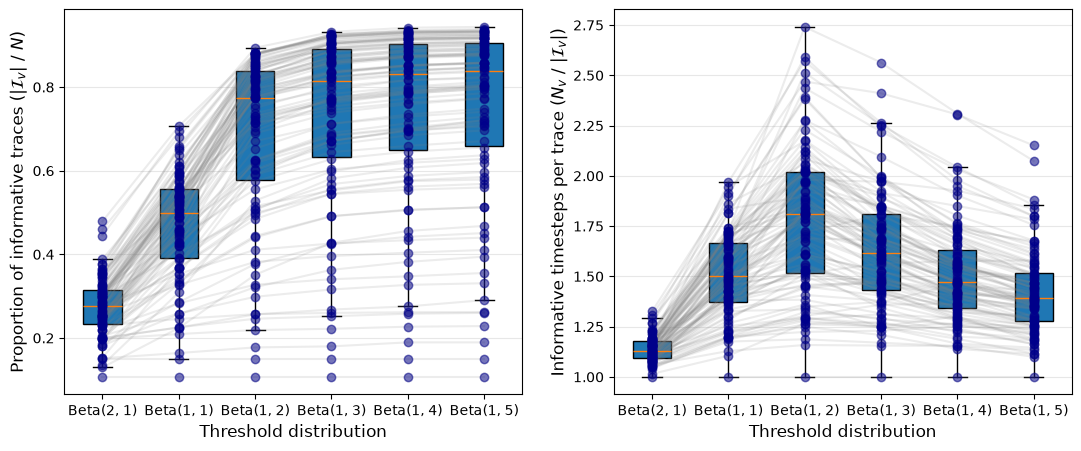

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(13, 5))
# fig.tight_layout(pad=2.0)
rotation = 0
fontsize=12



connected_boxplots(ab_2_Iv_div_N_over_vertices, labels=[f"Beta({a}, {b})" for a, b in ab_pairs], 
                   ax=axs[0], xlab=r"Threshold distribution", 
                   ylab=r"Proportion of informative traces ($|\mathcal{I}_v| \ / \ N$)", 
                   rotation=rotation, fontsize=fontsize)
# axs[0].text(2, 0.1, "$\longrightarrow$" + " Nodes are easier to influence")

connected_boxplots(ab_2_avg_Tv_over_vertices, labels=[f"Beta({a}, {b})" for a, b in ab_pairs], 
                   ax=axs[1], 
                   xlab="Threshold distribution",
                   ylab=r"Informative timesteps per trace ($N_v \ / \ |\mathcal{I}_v|$)", 
                   rotation=rotation, fontsize=fontsize)
plt.show()
                        

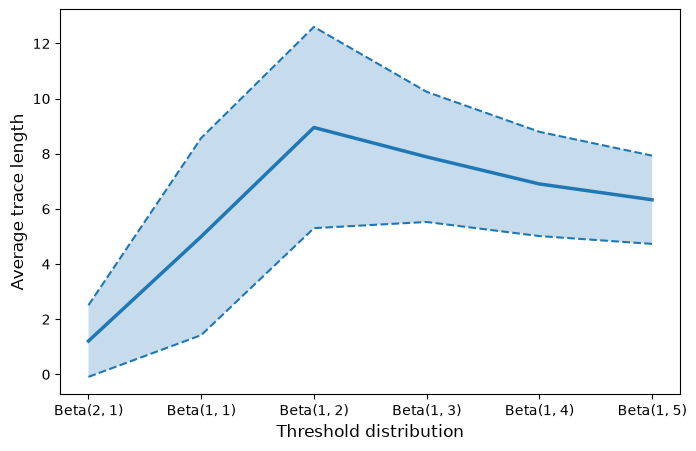

In [57]:
n_std = 1
lower_trace_len = np.array(avg_trace_lens) - n_std * np.array(std_trace_lens)
upper_trace_len = np.array(avg_trace_lens) + n_std * np.array(std_trace_lens)
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(avg_trace_lens, linewidth=2.5)
ax.plot(lower_trace_len, linewidth=1.5, linestyle="--", color=ax.lines[-1].get_color())
ax.plot(upper_trace_len, linewidth=1.5, linestyle="--", color=ax.lines[-1].get_color())
ax.fill_between(range(len(avg_trace_lens)), lower_trace_len, upper_trace_len, alpha=0.25)

ax.set_xlabel("Threshold distribution", fontsize=fontsize)
ax.set_ylabel("Average trace length", fontsize=fontsize)
ax.set_xticks(range(len(ab_pairs)), labels=[f"Beta({a}, {b})" for a, b in ab_pairs], 
                  rotation=rotation, fontsize=fontsize - 2)

plt.show()